In [27]:
"""
Clustering Teks (versi ringan, TANPA model pretrained / deep learning)
Alur: baca data -> cleaning -> EDA -> fitur (TF-IDF + SVD) -> coba beberapa k & algoritma
      -> pilih yang silhouette-nya terbaik -> interpretasi tiap cluster (kata dominan, word cloud,
      contoh teks, nama cluster, perbandingan ke label asli, ringkasan otomatis)

Install: pip install pandas numpy scikit-learn matplotlib wordcloud
(opsional) pip install PySastrawi               # kalau PAKAI_STEMMING = True dan bahasa Indonesia
(opsional) pip install nltk                    # kalau PAKAI_STEMMING = True dan bahasa Inggris
"""
import re
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import Normalizer, normalize
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score,
                             homogeneity_score, completeness_score, v_measure_score)

from wordcloud import WordCloud

In [28]:
# ============ PENGATURAN (ubah sesuai data) ============
FILE_DATA = r"C:\Users\Timothy\Downloads\dataset (1).csv"    # file data (xlsx -> ganti pd.read_csv jadi pd.read_excel di bagian 1)
KOLOM_TEKS = "Text Tweet"                # nama kolom teks (cek data.columns)
KOLOM_LABEL = None                 # label/kategori asli, hanya untuk MENILAI hasil (bukan untuk clustering).
                                   # None = tidak ada | "kategori" | ["acara", "sentimen"] (boleh lebih dari satu)
NAMA_CLUSTER = {}                  # nama cluster, isi SETELAH melihat kata dominan, mis. {0: "ILC", 1: "Kick Andy"}
                                   # kosong = nama otomatis dari 3 kata dominan

DAFTAR_MAX_FITUR = [3000, 5000]    # jumlah kata maksimal di TF-IDF yang dicoba
DAFTAR_NGRAM = [(1, 1), (1, 2)]    # unigram saja / unigram + bigram
DAFTAR_SVD = [50, 100]             # dimensi SVD yang dicoba
DAFTAR_ALGO = ["kmeans", "agglo"]  # kmeans | agglo | gmm
DAFTAR_K = range(2, 11)            # kecilkan batas atas kalau dokumen < 50
K_MANUAL = 6                    # None = otomatis dari silhouette, atau isi angka
MIN_UKURAN = 0.02                  # cluster < 2% data tidak boleh jadi pilihan terbaik

POLA_BUANG = r"[^a-z\s]"           # karakter yang dibuang (emoji, simbol, angka ikut terbuang). Simpan angka: r"[^a-z0-9\s]"
RAPIKAN_HURUF = True               # huruf berulang >= 3 kali jadi 1: "bagusssss" -> "bagus"
PAKAI_STEMMING = False             # True = stemming (lambat untuk data besar)
BAHASA_STEMMING = "id"             # id (Sastrawi) | en (Porter, butuh nltk)
MIN_KATA = 3                       # dokumen dengan kata < ini dibuang
SLANG = {"gak": "tidak", "ga": "tidak", "nggak": "tidak", "yg": "yang", "bgt": "banget",
         "tp": "tapi", "dgn": "dengan", "utk": "untuk", "krn": "karena"}   # tambah sendiri
STOPWORD_TAMBAHAN = []             # stopword khusus data kamu

JUMLAH_TOP = 12                    # kata teratas per cluster
CONTOH_PUSAT = 3                   # contoh teks per cluster yang paling mewakili (dekat pusat cluster)
CONTOH_ACAK = 2                    # contoh teks per cluster yang dipilih acak
PAKAI_WORDCLOUD = True
MAKS_SIL = 5000                    # data > ini: silhouette dihitung dari sampel
SEED = 42
# ========================================================

np.random.seed(SEED)

In [29]:
print(data.columns)

Index(['Id', 'Sentiment', 'Acara TV', 'Jumlah Retweet', 'Text Tweet', 'bersih', 'jml_kata', 'jml_huruf', 'cluster', 'silhouette', 'nama_cluster', 'x0', 'x1'], dtype='str')


In [30]:
daftar_label = [] if KOLOM_LABEL is None else ([KOLOM_LABEL] if isinstance(KOLOM_LABEL, str) else list(KOLOM_LABEL))

stopword_id = set("""yang dan di ke dari ini itu untuk dengan pada adalah dalam akan atau juga tidak ada saya kami kita
mereka dia anda nya sudah belum telah bisa dapat oleh karena agar sebagai saat lebih sangat sekali masih hanya
para sebuah seperti jika bila maka namun tetapi serta yaitu yakni tentang hingga sampai antara setelah sebelum
ia ya yg dgn utk dr krn tp sdh gak ga nggak aja sih deh dong banget""".split())
STOPWORD = list(stopword_id | set(ENGLISH_STOP_WORDS) | set(STOPWORD_TAMBAHAN))

stemmer = None
if PAKAI_STEMMING:
    if BAHASA_STEMMING == "id":
        from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
        stemmer = StemmerFactory().create_stemmer().stem
    else:
        from nltk.stem import PorterStemmer
        stemmer = PorterStemmer().stem
cache_stem = {}      # simpan hasil stem tiap kata supaya tidak diulang

In [31]:
# ---------- 1. PREPROCESSING: baca data + cleaning ----------
data = pd.read_csv(FILE_DATA)      # sep=";" / encoding="latin-1" / pd.read_excel(...) kalau perlu
jumlah_awal = len(data)
data = data.dropna(subset=[KOLOM_TEKS]).drop_duplicates(subset=[KOLOM_TEKS]).reset_index(drop=True)


def bersihkan(teks):
    teks = str(teks).lower()
    teks = re.sub(r"http\S+|www\.\S+", " ", teks)     # hapus link
    teks = re.sub(r"@\w+|#", " ", teks)               # hapus mention & hashtag
    if RAPIKAN_HURUF:
        teks = re.sub(r"([a-z])\1{2,}", r"\1", teks)  # bagusssss -> bagus
    teks = re.sub(POLA_BUANG, " ", teks)               # buang emoji, simbol, angka
    daftar_kata = [SLANG.get(k, k) for k in teks.split()]      # normalisasi slang
    if stemmer is not None:
        for i, k in enumerate(daftar_kata):
            if k not in cache_stem:
                cache_stem[k] = stemmer(k)
            daftar_kata[i] = cache_stem[k]
    return " ".join(daftar_kata)


data["bersih"] = data[KOLOM_TEKS].map(bersihkan)
data["jml_kata"] = data["bersih"].str.split().str.len()
data = data[data.jml_kata >= MIN_KATA].reset_index(drop=True)
data["jml_huruf"] = data[KOLOM_TEKS].astype(str).str.len()
for kol in daftar_label:
    assert kol in data.columns, f"KOLOM_LABEL '{kol}' tidak ada, kolom tersedia: {list(data.columns)}"
assert len(data) > 10, "Dokumen terlalu sedikit setelah cleaning, cek KOLOM_TEKS / POLA_BUANG / MIN_KATA"

print("Contoh sebelum -> sesudah cleaning:")
for i in range(min(3, len(data))):
    print("  -", str(data[KOLOM_TEKS][i])[:100].replace("\n", " "))
    print("   ", data["bersih"][i][:100])
print("(stopword baru dibuang di TF-IDF, jadi masih terlihat di sini)")

Contoh sebelum -> sesudah cleaning:
  - Undang @N_ShaniJKT48 ke hitamputih, pemenang SSK JKT48 harusnya mJKT48 ini lebih Layak di Undang kar
    undang ke hitamputih pemenang ssk jkt harusnya mjkt ini lebih layak di undang karena prestasinya
  - Selamat berbuka puasa Semoga amal ibadah hari ni diterima Allah #hitamputih
    selamat berbuka puasa semoga amal ibadah hari ni diterima allah hitamputih
  - Ada nih di trans7 hitam putih, dia dpt penghargaan juga di norwegia #hitamputih
    ada nih di trans hitam putih dia dpt penghargaan juga di norwegia hitamputih
(stopword baru dibuang di TF-IDF, jadi masih terlihat di sini)


Dokumen awal: 400 | dibuang: 1 | dipakai: 399
       jml_huruf  jml_kata
count      399.0     399.0
mean        80.0      11.1
std         30.6       4.6
min         22.0       3.0
25%         55.0       7.0
50%         77.0      10.0
75%        103.0      15.0
max        140.0      23.0
Ukuran kosakata: 483
Top kata  : kickandy(70), mata(61), najwa(60), ilc(54), ilctvone(46), hitam(40), matanajwametrotv(40), putih(39), hitamputiht(39), orang(35)
Top bigram: mata najwa(59), hitam putih(37), metro tv(18), putih trans(12), kick andy(10), acara mata(9), nonton mata(7), luar biasa(7), lawyers club(7), acara hitam(7)


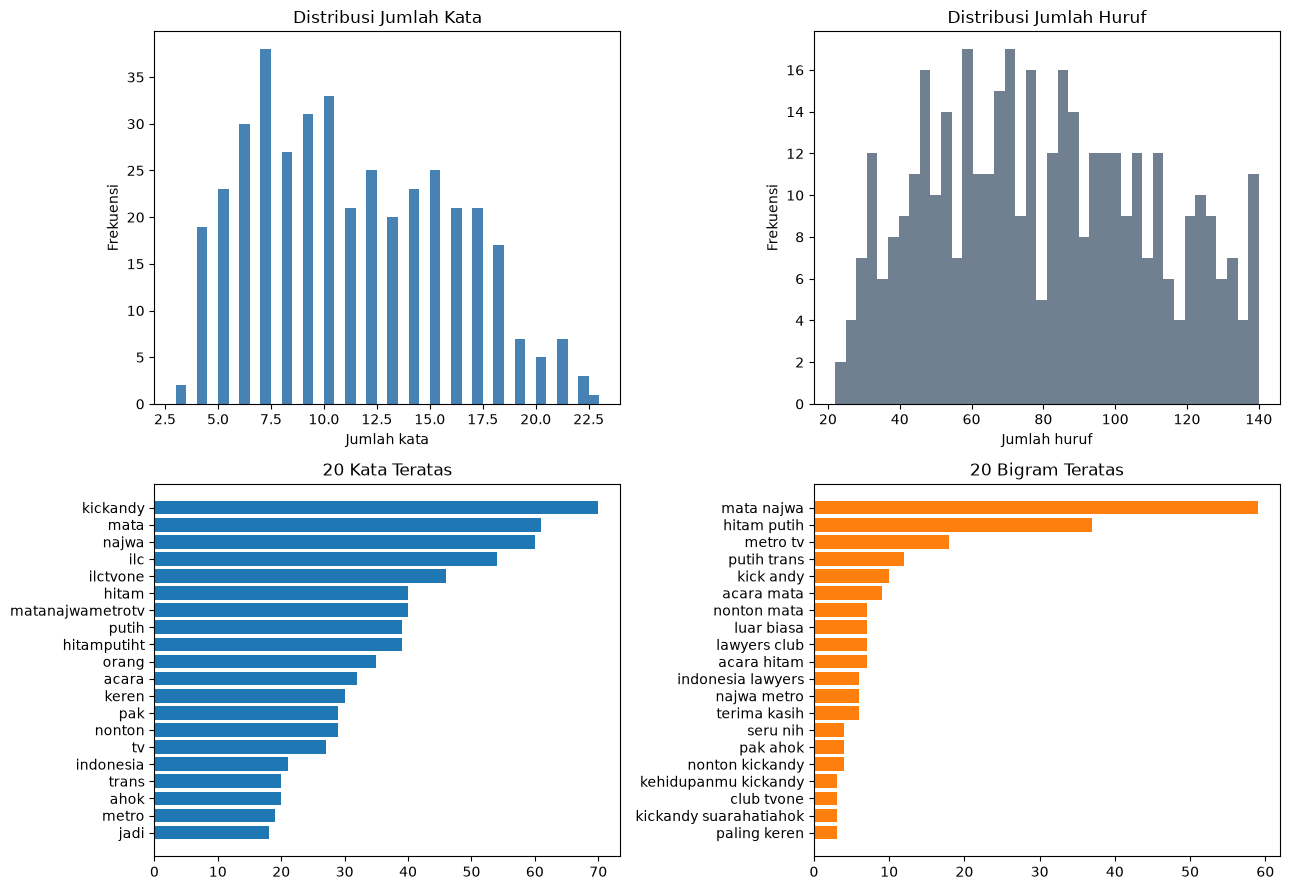

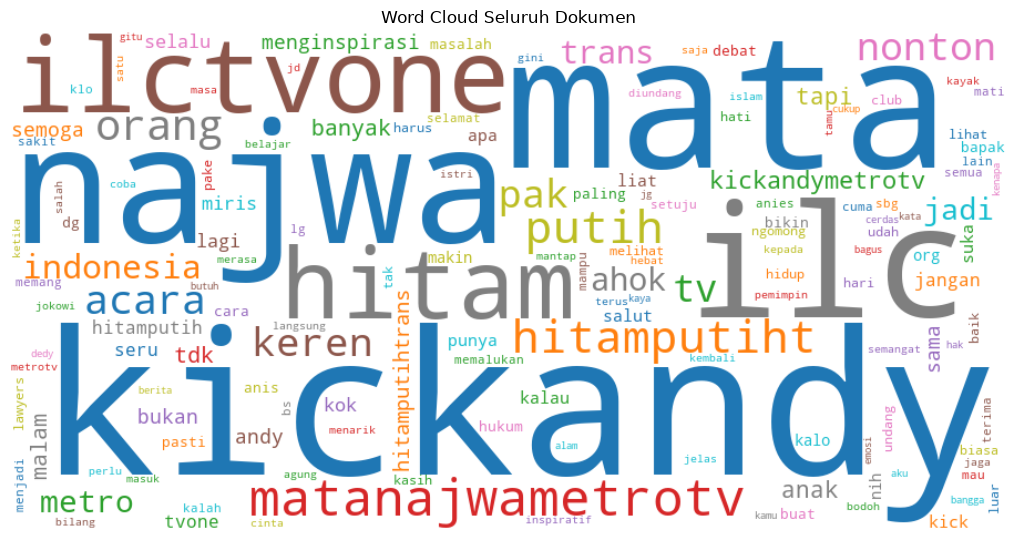

In [32]:
# ---------- 2. EDA ----------
print(f"Dokumen awal: {jumlah_awal} | dibuang: {jumlah_awal - len(data)} | dipakai: {len(data)}")
print(data[["jml_huruf", "jml_kata"]].describe().round(1))


def kata_teratas(ngram, n):
    """Return (kata teratas, frekuensinya, dict semua frekuensi)."""
    for md in (2, 1):
        try:
            cv = CountVectorizer(ngram_range=ngram, stop_words=STOPWORD, min_df=md)
            M = cv.fit_transform(data.bersih)
            frek = np.asarray(M.sum(axis=0)).ravel()
            kata = np.array(cv.get_feature_names_out())
            urut = frek.argsort()[::-1][:n]
            return kata[urut], frek[urut], {k: float(v) for k, v in zip(kata, frek) if v > 0}
        except ValueError:
            continue
    return np.array([]), np.array([]), {}


uni_kata, uni_frek, uni_semua = kata_teratas((1, 1), 20)
bi_kata, bi_frek, _ = kata_teratas((2, 2), 20)
print("Ukuran kosakata:", len(uni_semua))
print("Top kata  :", ", ".join(f"{k}({int(v)})" for k, v in zip(uni_kata[:10], uni_frek[:10])))
print("Top bigram:", ", ".join(f"{k}({int(v)})" for k, v in zip(bi_kata[:10], bi_frek[:10])))

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
ax[0, 0].hist(data.jml_kata, bins=40, color="steelblue")
ax[0, 0].set(title="Distribusi Jumlah Kata", xlabel="Jumlah kata", ylabel="Frekuensi")
ax[0, 1].hist(data.jml_huruf, bins=40, color="slategray")
ax[0, 1].set(title="Distribusi Jumlah Huruf", xlabel="Jumlah huruf", ylabel="Frekuensi")
ax[1, 0].barh(uni_kata[::-1], uni_frek[::-1], color="tab:blue"); ax[1, 0].set_title("20 Kata Teratas")
ax[1, 1].barh(bi_kata[::-1], bi_frek[::-1], color="tab:orange"); ax[1, 1].set_title("20 Bigram Teratas")
fig.tight_layout(); plt.show()

for kol in daftar_label:      # jumlah dokumen per kategori asli
    if data[kol].nunique() <= 50:
        fig, ax = plt.subplots(figsize=(7, 4))
        data[kol].value_counts().plot(kind="bar", ax=ax, color="tab:green")
        ax.set(title=f"Jumlah Dokumen per '{kol}'", ylabel="Jumlah"); fig.tight_layout(); plt.show()


def gambar_wordcloud(ax, frekuensi, judul):
    ax.axis("off"); ax.set_title(judul)
    if WordCloud is None or not frekuensi:
        ax.text(0.5, 0.5, "word cloud tidak tersedia", ha="center", va="center")
        return
    wc = WordCloud(width=900, height=450, background_color="white", max_words=150,
                   colormap="tab10", random_state=SEED).generate_from_frequencies(frekuensi)
    ax.imshow(wc, interpolation="bilinear")


if PAKAI_WORDCLOUD:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    gambar_wordcloud(ax, uni_semua, "Word Cloud Seluruh Dokumen")
    fig.tight_layout(); plt.show()

In [33]:
# ---------- 3. Fitur (semua kandidat) ----------
def buat_tfidf(max_fitur, ngram):
    for md in (2, 1):       # kalau kosakata habis, turunkan min_df
        try:
            v = TfidfVectorizer(max_features=max_fitur, ngram_range=ngram, min_df=md,
                                max_df=0.9, stop_words=STOPWORD, sublinear_tf=True)
            return v.fit_transform(data.bersih), np.array(v.get_feature_names_out())
        except ValueError:
            continue
    raise ValueError("Kosakata kosong, cek cleaning / stopword")


kandidat_fitur = {}   # nama -> (matriks untuk clustering, matriks tfidf, daftar kata)
for max_fitur, ngram in itertools.product(DAFTAR_MAX_FITUR, DAFTAR_NGRAM):
    tfidf, kata = buat_tfidf(max_fitur, ngram)
    for dim in DAFTAR_SVD:
        dim = min(dim, tfidf.shape[1] - 1, tfidf.shape[0] - 1)
        if dim < 2:
            continue
        Xr = Normalizer().fit_transform(TruncatedSVD(dim, random_state=SEED).fit_transform(tfidf))
        kandidat_fitur[f"tfidf max={max_fitur} ngram={ngram} svd={dim}"] = (Xr, tfidf, kata)
print("Jumlah kandidat fitur:", len(kandidat_fitur))

Jumlah kandidat fitur: 8


In [34]:
# ---------- 4. Coba beberapa pengaturan ----------
def buat_model(algo, k):
    if algo == "kmeans":
        return KMeans(n_clusters=k, n_init=10, random_state=SEED)
    if algo == "agglo":
        return AgglomerativeClustering(n_clusters=k, linkage="ward")
    if algo == "gmm":
        return GaussianMixture(n_components=k, covariance_type="diag", random_state=SEED)
    raise ValueError("algo tidak dikenal: " + algo)


def hitung_sil(Xr, lab):
    sampel = MAKS_SIL if len(Xr) > MAKS_SIL else None
    return silhouette_score(Xr, lab, metric="cosine", sample_size=sampel, random_state=SEED)


baris = []
for nama, (Xr, _, _) in kandidat_fitur.items():
    for algo in DAFTAR_ALGO:
        for k in DAFTAR_K:
            model = buat_model(algo, k)
            lab = model.fit_predict(Xr)
            if len(set(lab)) < 2:
                continue
            baris.append(dict(fitur=nama, algo=algo, k=k, silhouette=hitung_sil(Xr, lab),
                              davies_bouldin=davies_bouldin_score(Xr, lab),
                              calinski=calinski_harabasz_score(Xr, lab),
                              inertia=getattr(model, "inertia_", np.nan),
                              cluster_terkecil=int(np.bincount(lab).min())))
hasil_percobaan = pd.DataFrame(baris)

pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 60)
print("\n=== 15 percobaan terbaik (urut silhouette) ===")
print(hasil_percobaan.sort_values("silhouette", ascending=False).head(15).round(4).to_string(index=False))
print("\n=== Terbaik untuk tiap (fitur, algo) ===")
print(hasil_percobaan.loc[hasil_percobaan.groupby(["fitur", "algo"]).silhouette.idxmax()].round(4).to_string(index=False))

kandidat = hasil_percobaan if K_MANUAL is None else hasil_percobaan[hasil_percobaan.k == K_MANUAL]
kandidat_aman = kandidat[kandidat.cluster_terkecil >= max(2, MIN_UKURAN * len(data))]
if len(kandidat_aman) > 0:
    kandidat = kandidat_aman
terbaik = kandidat.sort_values("silhouette", ascending=False).iloc[0]
fitur_terbaik, algo_terbaik, k_terbaik = terbaik.fitur, terbaik.algo, int(terbaik.k)
Xr, tfidf, kata = kandidat_fitur[fitur_terbaik]
print(f"\n>>> Dipilih: {fitur_terbaik} | algo={algo_terbaik} | k={k_terbaik} (silhouette={terbaik.silhouette:.4f})")


=== 15 percobaan terbaik (urut silhouette) ===
                             fitur   algo  k  silhouette  davies_bouldin  calinski  inertia  cluster_terkecil
tfidf max=3000 ngram=(1, 1) svd=50 kmeans 10      0.2553          2.7771   17.4402 267.6302                14
tfidf max=5000 ngram=(1, 1) svd=50 kmeans 10      0.2553          2.7771   17.4402 267.6302                14
tfidf max=3000 ngram=(1, 2) svd=50 kmeans  9      0.2496          2.7953   18.9991 270.6779                27
tfidf max=5000 ngram=(1, 2) svd=50 kmeans  9      0.2496          2.7953   18.9991 270.6779                27
tfidf max=3000 ngram=(1, 2) svd=50 kmeans  8      0.2471          2.9031   19.9457 277.1884                37
tfidf max=5000 ngram=(1, 2) svd=50 kmeans  8      0.2471          2.9031   19.9457 277.1884                37
tfidf max=5000 ngram=(1, 1) svd=50 kmeans  9      0.2468          2.8075   18.2224 273.4175                14
tfidf max=3000 ngram=(1, 1) svd=50 kmeans  9      0.2468          2.8075


=== Elbow (KMeans) ===
  tfidf max=3000 ngram=(1, 1) svd=50: elbow di k = 7
  tfidf max=3000 ngram=(1, 1) svd=100: elbow di k = 6
  tfidf max=3000 ngram=(1, 2) svd=50: elbow di k = 7
  tfidf max=3000 ngram=(1, 2) svd=100: elbow di k = 6
  tfidf max=5000 ngram=(1, 1) svd=50: elbow di k = 7
  tfidf max=5000 ngram=(1, 1) svd=100: elbow di k = 6
  tfidf max=5000 ngram=(1, 2) svd=50: elbow di k = 7
  tfidf max=5000 ngram=(1, 2) svd=100: elbow di k = 6


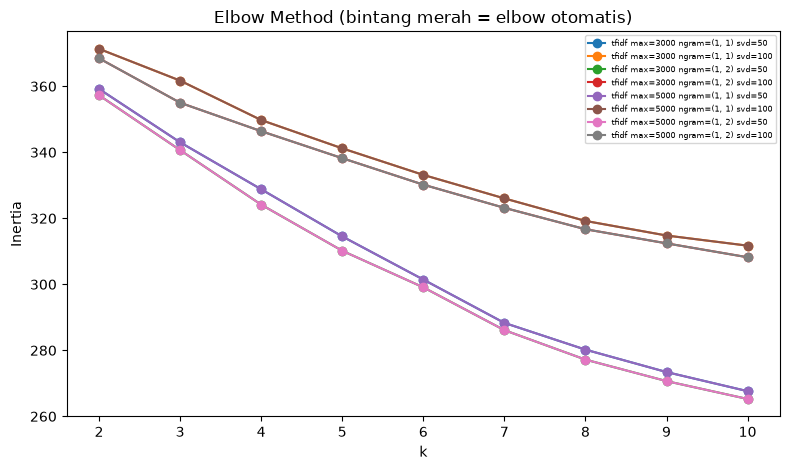

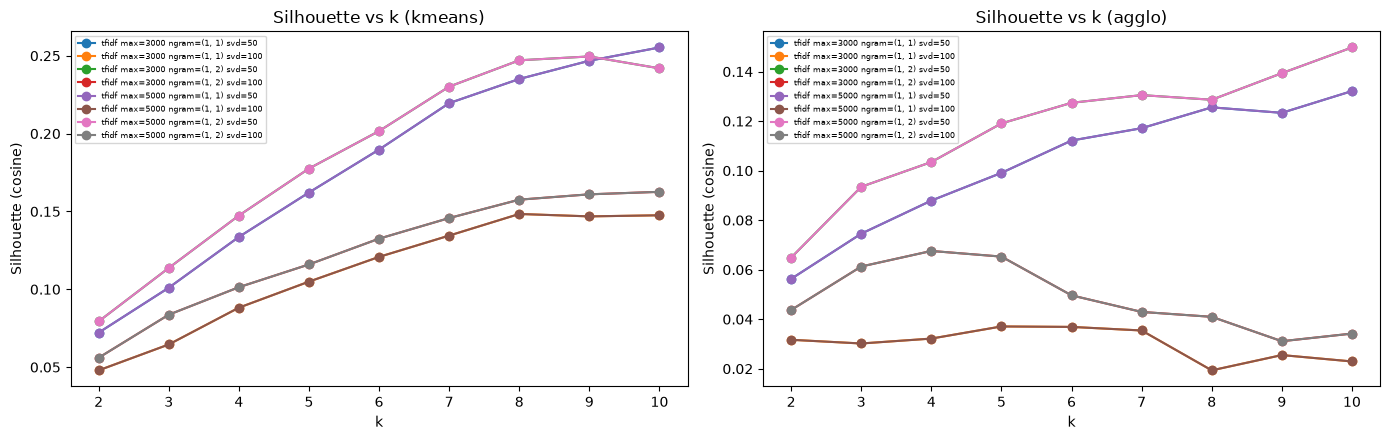

In [35]:
# ---------- 5. Plot elbow dan silhouette vs k ----------
def cari_elbow(ks, ys):
    """Titik yang paling jauh dari garis lurus ujung-ke-ujung kurva."""
    ks, ys = np.array(ks, float), np.array(ys, float)
    if len(ks) < 3 or ys.max() == ys.min():
        return int(ks[0])
    x = (ks - ks.min()) / (ks.max() - ks.min())
    y = (ys - ys.min()) / (ys.max() - ys.min())
    return int(ks[np.abs(x + y - 1).argmax()])


if "kmeans" in DAFTAR_ALGO:
    fig, ax = plt.subplots(figsize=(8, 4.8))
    print("\n=== Elbow (KMeans) ===")
    for nama in kandidat_fitur:
        d = hasil_percobaan[(hasil_percobaan.algo == "kmeans") & (hasil_percobaan.fitur == nama)].sort_values("k")
        if d.empty:
            continue
        ax.plot(d.k, d.inertia, "o-", label=nama)
        k_elbow = cari_elbow(d.k, d.inertia)
        print(f"  {nama}: elbow di k = {k_elbow}")
    ax.set(title="Elbow Method (bintang merah = elbow otomatis)", xlabel="k", ylabel="Inertia")
    ax.legend(fontsize=6); fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(DAFTAR_ALGO), figsize=(7 * len(DAFTAR_ALGO), 4.5), squeeze=False)
for a, algo in zip(axes[0], DAFTAR_ALGO):
    for nama in kandidat_fitur:
        d = hasil_percobaan[(hasil_percobaan.algo == algo) & (hasil_percobaan.fitur == nama)].sort_values("k")
        a.plot(d.k, d.silhouette, "o-", label=nama)
    a.set(title=f"Silhouette vs k ({algo})", xlabel="k", ylabel="Silhouette (cosine)"); a.legend(fontsize=6)
fig.tight_layout(); plt.show()

In [36]:
# ---------- 6. Model final + evaluasi ----------
label = buat_model(algo_terbaik, k_terbaik).fit_predict(Xr)
sil_total = silhouette_score(Xr, label, metric="cosine")
sil_sampel = silhouette_samples(Xr, label, metric="cosine")
print(f"\nSilhouette Score  : {sil_total:.4f}")
print(f"Davies-Bouldin    : {davies_bouldin_score(Xr, label):.4f}  (makin kecil makin bagus)")
print(f"Calinski-Harabasz : {calinski_harabasz_score(Xr, label):.2f}  (makin besar makin bagus)")

data["cluster"] = label
data["silhouette"] = sil_sampel
daftar_cluster = sorted(set(label))
print("\nJumlah dokumen per cluster:\n", data["cluster"].value_counts().sort_index())
print("\nRata-rata silhouette per cluster:\n", data.groupby("cluster")["silhouette"].mean().round(4))
print("\nRata-rata panjang dokumen per cluster:\n", data.groupby("cluster")[["jml_kata", "jml_huruf"]].mean().round(1))


Silhouette Score  : 0.2016
Davies-Bouldin    : 2.9608  (makin kecil makin bagus)
Calinski-Harabasz : 20.26  (makin besar makin bagus)

Jumlah dokumen per cluster:
 cluster
0     73
1     58
2    142
3     44
4     36
5     46
Name: count, dtype: int64

Rata-rata silhouette per cluster:
 cluster
0    0.1638
1    0.3679
2    0.0402
3    0.2225
4    0.4915
5    0.3037
Name: silhouette, dtype: float64

Rata-rata panjang dokumen per cluster:
          jml_kata  jml_huruf
cluster                     
0            11.2       83.5
1            13.2       86.6
2            10.2       76.0
3            10.8       80.7
4            12.2       80.6
5            10.6       77.7



=== Cluster 0: kickandy, orang, menginspirasi (n=73) ===
Kata teratas: kickandy, orang, menginspirasi, anak, banyak, semangat, jadi, jangan, stress, mampu, ahok, nonton kickandy
Contoh paling mewakili:
  - Kickandy gokil #kickandy
  - Temukan lentera jiwamu #kickandy #mahasiswaum
  - sampan tidak akan dapat belayar di padang pasir betapa pun jua emp http://ilha8253.m.nomor1.net/ilha8253/1001-burung-kertas.htm … #kickandy
Contoh acak:
  - #kickandy @KickAndyShow siang ini jg jadi ajang reuni sahabat kosti DKI dan kosti Jateng
  - inilah jagoan saya!! hahahaha #kickandy

=== Cluster 1: najwa, mata najwa, mata (n=58) ===
Kata teratas: najwa, mata najwa, mata, tv, metro, metro tv, acara, acara mata, keren, nonton mata, anies, nonton
Contoh paling mewakili:
  - Suarakan terus kebenaran Mata Najwa
  - keren deh. Mata Najwa juga.
  - kayaknya mata Najwa mengadu domba kedua cagub di putaran 2 Pilkada DKI nih...
Contoh acak:
  - metro tv keren inspiratif dgn mata najwa nya kick andy
  - Nyetel

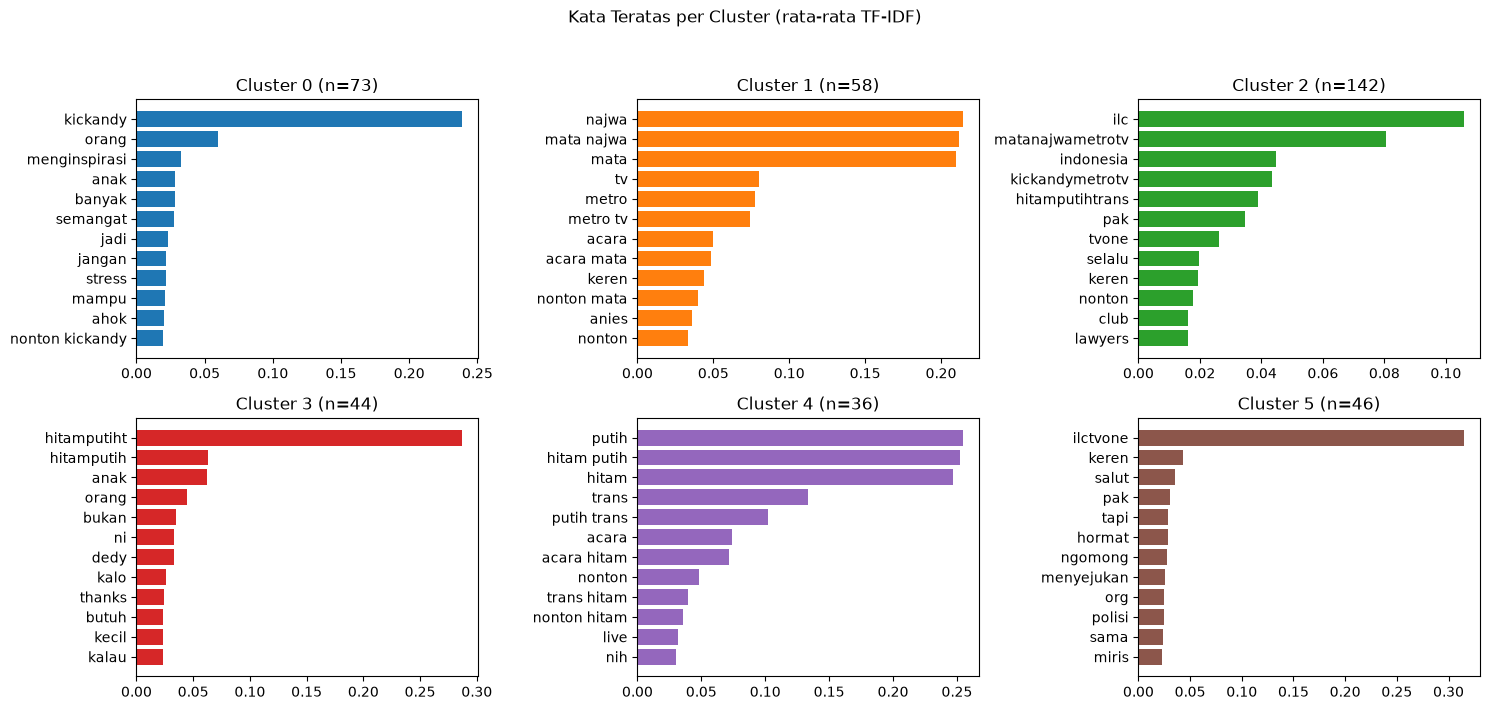

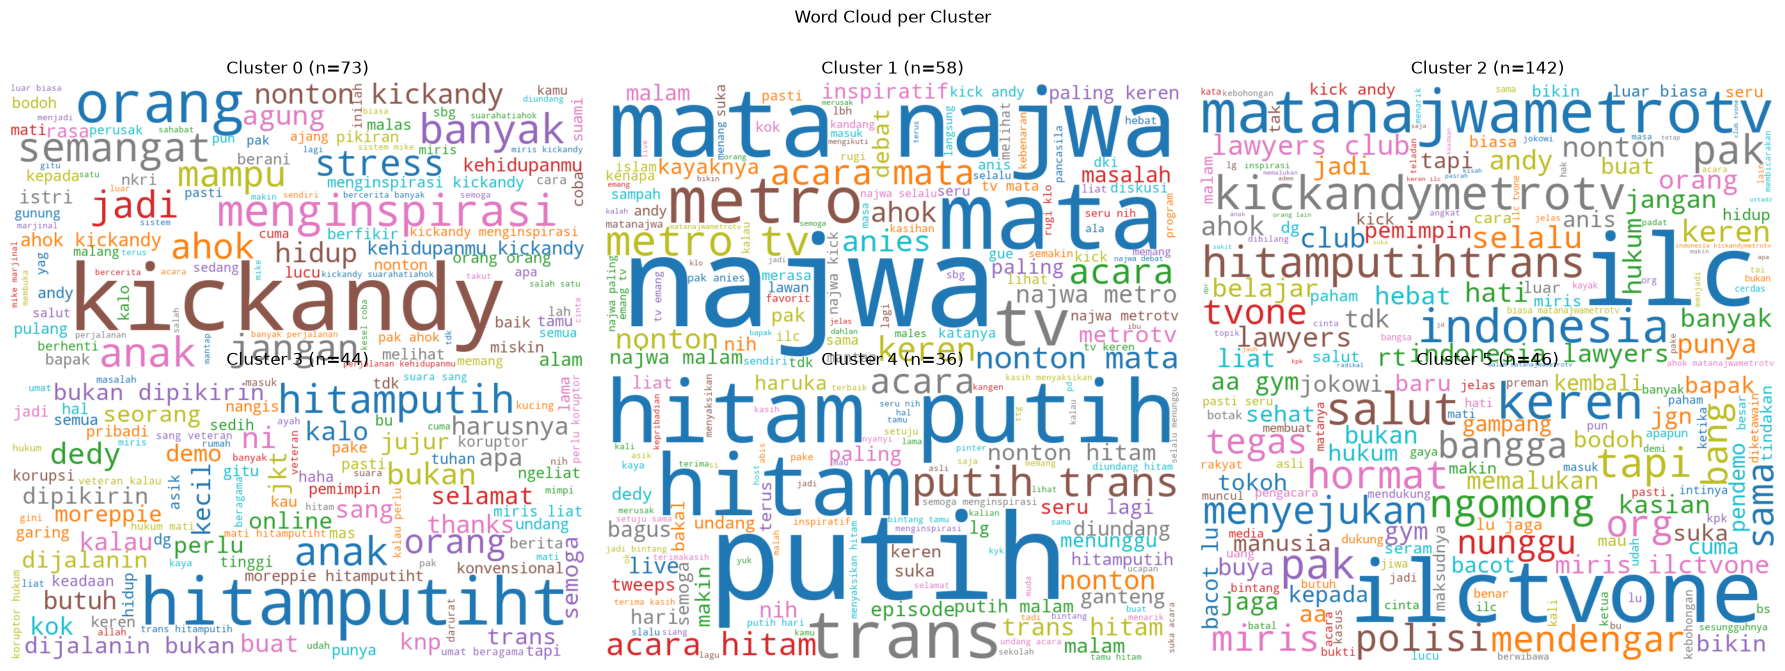

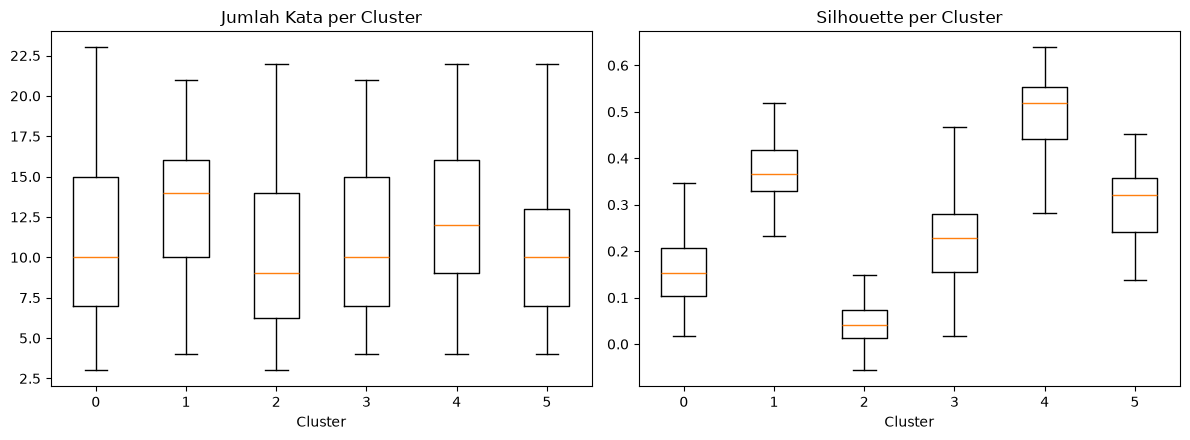

In [41]:
# ---------- 7. Interpretasi tiap cluster ----------
top_kata, top_bobot, frek_cluster, rata_tfidf, nama_cluster = {}, {}, {}, {}, {}
for c in daftar_cluster:
    rata = np.asarray(tfidf[label == c].mean(axis=0)).ravel()
    urut = rata.argsort()[::-1]
    top_kata[c], top_bobot[c] = kata[urut[:JUMLAH_TOP]], rata[urut[:JUMLAH_TOP]]
    frek_cluster[c] = {kata[j]: float(rata[j]) for j in urut[:100] if rata[j] > 0}
    rata_tfidf[c] = rata
    nama_cluster[c] = NAMA_CLUSTER.get(c, ", ".join(top_kata[c][:3]))     # nama manual, atau 3 kata dominan
    print(f"\n=== Cluster {c}: {nama_cluster[c]} (n={np.sum(label == c)}) ===")
    print("Kata teratas:", ", ".join(top_kata[c]))
    anggota = np.where(label == c)[0]
    pusat = Xr[anggota].mean(axis=0)
    urut_pusat = anggota[np.argsort(np.linalg.norm(Xr[anggota] - pusat, axis=1))]
    print("Contoh paling mewakili:")
    for i in urut_pusat[:CONTOH_PUSAT]:
        print("  -", str(data[KOLOM_TEKS][i])[:200].replace("\n", " "))
    sisa = urut_pusat[CONTOH_PUSAT:]
    acak = np.random.RandomState(SEED + int(c)).choice(sisa, size=min(CONTOH_ACAK, len(sisa)), replace=False) if len(sisa) else []
    if len(acak):
        print("Contoh acak:")
        for i in acak:
            print("  -", str(data[KOLOM_TEKS][i])[:200].replace("\n", " "))
data["nama_cluster"] = data["cluster"].map(nama_cluster)
print("\nUntuk memberi nama sendiri, isi NAMA_CLUSTER di bagian pengaturan lalu jalankan ulang, contoh:")
print("  NAMA_CLUSTER = {" + ", ".join(f'{c}: "..."' for c in daftar_cluster) + "}")

kolom = min(3, len(daftar_cluster)); baris = int(np.ceil(len(daftar_cluster) / kolom))
fig, axes = plt.subplots(baris, kolom, figsize=(5 * kolom, 3.6 * baris), squeeze=False)
for a in axes.ravel():
    a.axis("off")
for a, c in zip(axes.ravel(), daftar_cluster):
    a.axis("on")
    a.barh(top_kata[c][::-1], top_bobot[c][::-1], color=plt.cm.tab10(c % 10))
    a.set_title(f"Cluster {c} (n={np.sum(label == c)})")
fig.suptitle("Kata Teratas per Cluster (rata-rata TF-IDF)"); fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

if PAKAI_WORDCLOUD:
    fig, axes = plt.subplots(baris, kolom, figsize=(6 * kolom, 3.4 * baris), squeeze=False)
    for a in axes.ravel():
        a.axis("off")
    for a, c in zip(axes.ravel(), daftar_cluster):
        gambar_wordcloud(a, frek_cluster[c], f"Cluster {c} (n={np.sum(label == c)})")
    fig.suptitle("Word Cloud per Cluster"); fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

# panjang dokumen & silhouette per cluster
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].boxplot([data.jml_kata[label == c] for c in daftar_cluster], showfliers=False)
ax[0].set_xticklabels([str(c) for c in daftar_cluster]); ax[0].set(title="Jumlah Kata per Cluster", xlabel="Cluster")
ax[1].boxplot([data.silhouette[label == c] for c in daftar_cluster], showfliers=False)
ax[1].set_xticklabels([str(c) for c in daftar_cluster]); ax[1].set(title="Silhouette per Cluster", xlabel="Cluster")
fig.tight_layout(); plt.show()

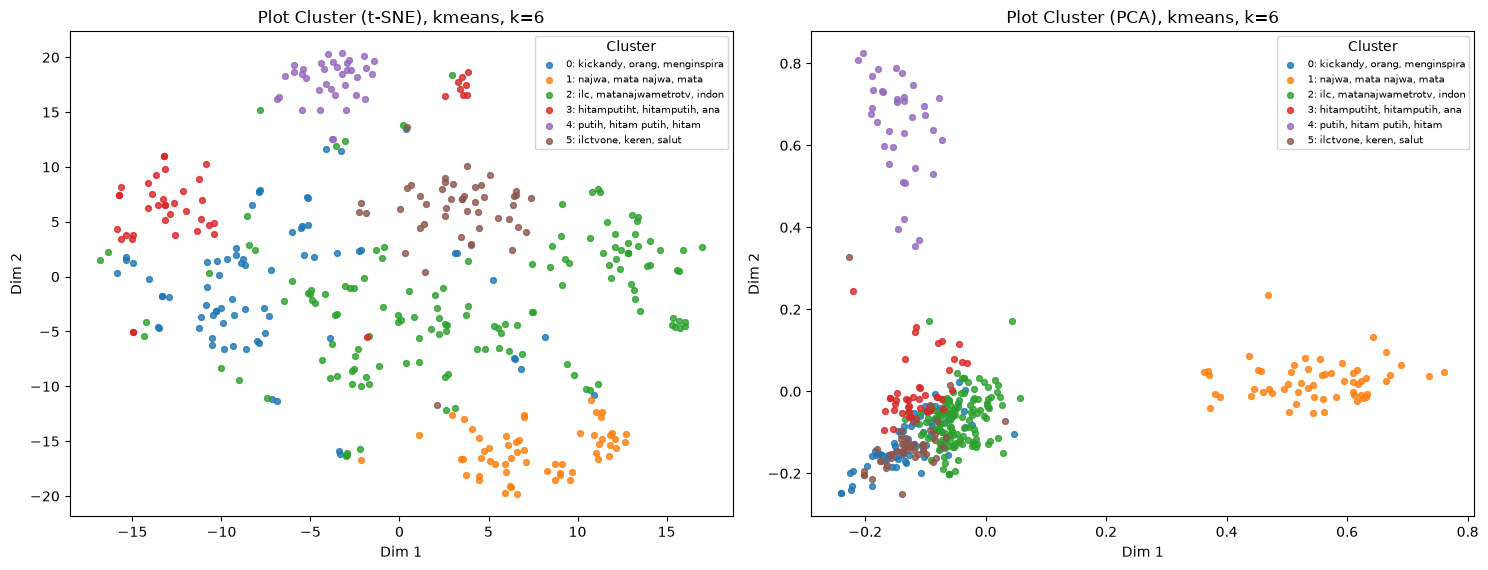

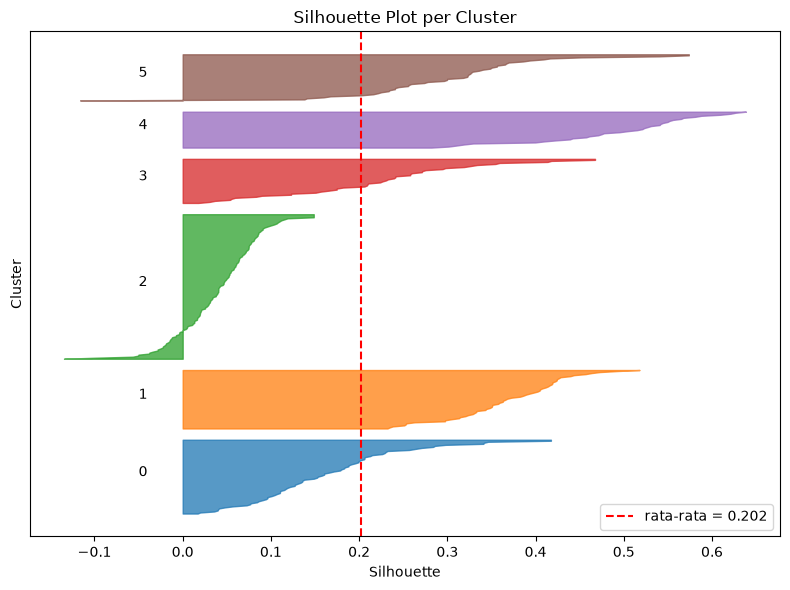

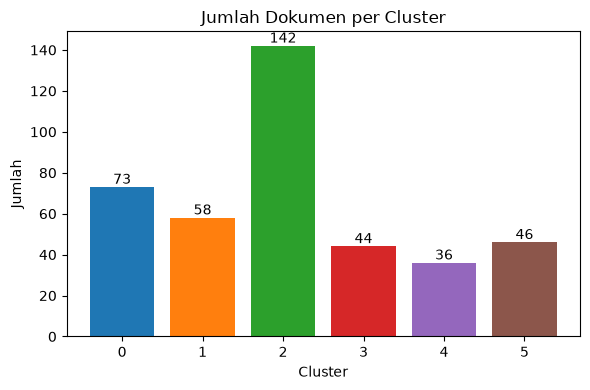

In [42]:
# ---------- 8. Plot cluster 2D, silhouette plot, ukuran cluster ----------
tsne = TSNE(n_components=2, perplexity=max(2, min(30, (len(Xr) - 1) / 3)), random_state=SEED,
            init="pca", learning_rate="auto", metric="cosine").fit_transform(Xr)
pca2 = PCA(n_components=2, random_state=SEED).fit_transform(Xr)
data["x0"], data["x1"] = pca2[:, 0], pca2[:, 1]          # koordinat PCA 2D tiap dokumen
fig, ax = plt.subplots(1, 2, figsize=(15, 5.8))
for a, hasil_2d, nama in zip(ax, [tsne, pca2], ["t-SNE", "PCA"]):
    for c in daftar_cluster:
        m = label == c
        a.scatter(hasil_2d[m, 0], hasil_2d[m, 1], color=plt.cm.tab10(c % 10), s=18, alpha=.8,
                  label=f"{c}: {nama_cluster[c][:28]}")
    a.set(title=f"Plot Cluster ({nama}), {algo_terbaik}, k={k_terbaik}", xlabel="Dim 1", ylabel="Dim 2")
    a.legend(title="Cluster", fontsize=7)
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
bawah = 10
for c in daftar_cluster:
    s = np.sort(sil_sampel[label == c]); atas = bawah + len(s)
    ax.fill_betweenx(np.arange(bawah, atas), 0, s, alpha=.75, color=plt.cm.tab10(c % 10))
    ax.text(-0.05, bawah + .5 * len(s), str(c)); bawah = atas + 10
ax.axvline(sil_total, c="red", ls="--", label=f"rata-rata = {sil_total:.3f}")
ax.set(title="Silhouette Plot per Cluster", xlabel="Silhouette", ylabel="Cluster", yticks=[])
ax.legend(); fig.tight_layout(); plt.show()

jumlah = data["cluster"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(jumlah.index.astype(str), jumlah.values, color=[plt.cm.tab10(i % 10) for i in jumlah.index])
for i, v in enumerate(jumlah.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
ax.set(title="Jumlah Dokumen per Cluster", xlabel="Cluster", ylabel="Jumlah")
fig.tight_layout(); plt.show()

In [39]:
# ---------- 9. EVALUASI EKSTERNAL (bandingkan cluster dengan label asli) ----------
def evaluasi_eksternal(label_asli, label_cluster, nama_label):
    """Purity, ARI, NMI, homogeneity, completeness, V-measure + crosstab & heatmap.
    Label asli HANYA dipakai untuk menilai hasil, bukan untuk clustering."""
    label_asli = pd.Series(np.asarray(label_asli)).astype(str)
    label_cluster = pd.Series(np.asarray(label_cluster))
    tabel = pd.crosstab(label_cluster, label_asli); tabel.index.name = "cluster"
    purity_c = tabel.max(axis=1) / tabel.sum(axis=1)
    ringkas = pd.DataFrame({"n": tabel.sum(axis=1), "label_dominan": tabel.idxmax(axis=1),
                            "purity": purity_c.round(4)})
    purity_total = tabel.max(axis=1).sum() / tabel.values.sum()
    ari = adjusted_rand_score(label_asli, label_cluster)
    nmi = normalized_mutual_info_score(label_asli, label_cluster)

    print(f"\n=== EVALUASI EKSTERNAL (vs {nama_label}) ===")
    print("Crosstab cluster x label:\n", tabel)
    print("\nPurity per cluster:\n", ringkas.to_string())
    print(f"\nPurity (overall)   : {purity_total:.4f}  (1 = tiap cluster berisi satu label saja)")
    print(f"Adjusted Rand Index: {ari:.4f}  (1 = cocok sempurna, ~0 = acak)")
    print(f"NMI                : {nmi:.4f}  (1 = cocok sempurna)")
    print(f"Homogeneity        : {homogeneity_score(label_asli, label_cluster):.4f}  (tiap cluster berisi satu label)")
    print(f"Completeness       : {completeness_score(label_asli, label_cluster):.4f}  (satu label tidak terpecah ke banyak cluster)")
    print(f"V-measure          : {v_measure_score(label_asli, label_cluster):.4f}  (gabungan keduanya)")
    if label_asli.nunique() > label_cluster.nunique():
        print("Catatan: jumlah label asli > jumlah cluster, purity wajar rendah dan completeness tidak bisa tinggi.")
    if label_cluster.nunique() > label_asli.nunique():
        print("Catatan: purity cenderung naik kalau jumlah cluster diperbanyak, jangan dipakai sendirian.")

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
    norm = tabel.div(tabel.sum(axis=1), axis=0)
    im = ax[0].imshow(norm.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax[0].set_xticks(range(norm.shape[1])); ax[0].set_xticklabels([str(c)[:14] for c in norm.columns], rotation=60, ha="right", fontsize=8)
    ax[0].set_yticks(range(norm.shape[0])); ax[0].set_yticklabels([f"Cluster {c}" for c in norm.index])
    if norm.shape[0] * norm.shape[1] <= 120:
        for i in range(norm.shape[0]):
            for j in range(norm.shape[1]):
                ax[0].text(j, i, str(tabel.values[i, j]), ha="center", va="center", fontsize=7,
                           color="white" if norm.values[i, j] > .55 else "black")
    fig.colorbar(im, ax=ax[0], label="proporsi per cluster"); ax[0].set_title(f"Cluster vs '{nama_label}'")
    ax[1].bar([str(c) for c in purity_c.index], purity_c.values, color=[plt.cm.tab10(int(i) % 10) for i in purity_c.index])
    ax[1].axhline(purity_total, c="red", ls="--", label=f"overall = {purity_total:.3f}")
    ax[1].set(title="Purity per Cluster", xlabel="Cluster", ylim=(0, 1.05)); ax[1].legend()
    fig.tight_layout(); plt.show()
    return dict(ringkas=ringkas, purity=purity_total, ari=ari, nmi=nmi)


hasil_label = {}
for kol in daftar_label:
    if data[kol].nunique() > 50:
        print(f"\nKolom '{kol}' dilewati: terlalu banyak nilai unik ({data[kol].nunique()}), bukan label kategori.")
        continue
    ada = data[kol].notna()
    hasil_label[kol] = evaluasi_eksternal(data.loc[ada, kol], data.loc[ada, "cluster"], kol)
if not daftar_label:
    print("\nKOLOM_LABEL = None -> evaluasi eksternal (purity, ARI, NMI) dilewati.")


KOLOM_LABEL = None -> evaluasi eksternal (purity, ARI, NMI) dilewati.


In [40]:
# ---------- 10. RINGKASAN INTERPRETASI (otomatis) ----------
def interpretasi_silhouette(nilai):      # patokan Kaufman & Rousseeuw
    if nilai > 0.70: return "struktur cluster kuat"
    if nilai > 0.50: return "struktur cluster cukup baik"
    if nilai > 0.25: return "struktur lemah, cluster sebagian tumpang tindih"
    return "tidak ada struktur yang tegas, cluster banyak tumpang tindih"


def interpretasi_db(nilai):              # patokan kasar
    if nilai < 1: return "pemisahan antar cluster baik"
    if nilai < 2: return "pemisahan antar cluster sedang"
    return "pemisahan antar cluster lemah"


db_total = davies_bouldin_score(Xr, label)
baris_ringkasan = []
for c in daftar_cluster:
    n = int(np.sum(label == c))
    baris_c = {"cluster": c, "nama": nama_cluster[c], "n": n, "persen": round(100 * n / len(data), 1),
               "kata_dominan": ", ".join(top_kata[c][:6]),
               "silhouette_rata2": round(float(data.silhouette[label == c].mean()), 3)}
    for kol, h in hasil_label.items():
        if c in h["ringkas"].index:
            baris_c[f"{kol}_dominan"] = h["ringkas"].loc[c, "label_dominan"]
            baris_c[f"{kol}_purity"] = h["ringkas"].loc[c, "purity"]
    baris_ringkasan.append(baris_c)
ringkasan_cluster = pd.DataFrame(baris_ringkasan)

print("\n" + "=" * 78)
print("RINGKASAN INTERPRETASI HASIL CLUSTERING")
print("=" * 78)
print(f"Metode : {fitur_terbaik} | {algo_terbaik} | k={k_terbaik} | jumlah dokumen={len(data)}")
print("\n[Evaluasi]")
print(f"- Silhouette = {sil_total:.3f} -> {interpretasi_silhouette(sil_total)}.")
print(f"- Davies-Bouldin = {db_total:.3f} -> {interpretasi_db(db_total)}.")
if data.jml_kata.median() < 15:
    print(f"- Dokumen tergolong pendek (median {data.jml_kata.median():.0f} kata), jadi vektor TF-IDF banyak bernilai nol "
          "dan silhouette yang rendah wajar.")
for kol, h in hasil_label.items():
    print(f"- Terhadap label '{kol}': purity={h['purity']:.3f}, ARI={h['ari']:.3f}, NMI={h['nmi']:.3f}.")

print("\n[Isi tiap cluster]")
for c in daftar_cluster:
    b = ringkasan_cluster[ringkasan_cluster.cluster == c].iloc[0]
    rapat = "relatif padat" if b.silhouette_rata2 >= sil_total else "lebih longgar / tumpang tindih"
    teks = (f"- Cluster {c} ({b.nama}): n={b.n} ({b.persen}%). Kata dominan: {b.kata_dominan}. "
            f"Silhouette rata-rata {b.silhouette_rata2:.3f} ({rapat}).")
    for kol in hasil_label:
        if f"{kol}_dominan" in b:
            teks += f" Label '{kol}' dominan: {b[f'{kol}_dominan']} (purity {b[f'{kol}_purity']:.0%})."
    panjang = [k for k in top_kata[c][:5] if len(k) >= 12 and " " not in k]
    if len(panjang) >= 2:
        teks += (f" Catatan: kata dominan berupa token panjang ({', '.join(panjang)}), kemungkinan hashtag/kata gabungan; "
                 "pertimbangkan dipecah atau dinormalisasi di cleaning.")
    print(teks)

terbaik_c = ringkasan_cluster.sort_values("silhouette_rata2").iloc[-1]
terburuk_c = ringkasan_cluster.sort_values("silhouette_rata2").iloc[0]
print("\n[Ringkasan]")
print(f"- Cluster paling padat   : {int(terbaik_c.cluster)} ({terbaik_c.nama}), silhouette {terbaik_c.silhouette_rata2:.3f}")
print(f"- Cluster paling longgar : {int(terburuk_c.cluster)} ({terburuk_c.nama}), silhouette {terburuk_c.silhouette_rata2:.3f}")
print(f"- Cluster terbesar       : {int(ringkasan_cluster.sort_values('n').iloc[-1].cluster)} "
      f"({ringkasan_cluster.n.max()} dokumen), terkecil: {int(ringkasan_cluster.sort_values('n').iloc[0].cluster)} "
      f"({ringkasan_cluster.n.min()} dokumen)")
print("\nTabel ringkasan cluster:")
print(ringkasan_cluster.to_string(index=False))


RINGKASAN INTERPRETASI HASIL CLUSTERING
Metode : tfidf max=3000 ngram=(1, 2) svd=50 | kmeans | k=6 | jumlah dokumen=399

[Evaluasi]
- Silhouette = 0.202 -> tidak ada struktur yang tegas, cluster banyak tumpang tindih.
- Davies-Bouldin = 2.961 -> pemisahan antar cluster lemah.
- Dokumen tergolong pendek (median 10 kata), jadi vektor TF-IDF banyak bernilai nol dan silhouette yang rendah wajar.

[Isi tiap cluster]
- Cluster 0 (kickandy, orang, menginspirasi): n=73 (18.3%). Kata dominan: kickandy, orang, menginspirasi, anak, banyak, semangat. Silhouette rata-rata 0.164 (lebih longgar / tumpang tindih).
- Cluster 1 (najwa, mata najwa, mata): n=58 (14.5%). Kata dominan: najwa, mata najwa, mata, tv, metro, metro tv. Silhouette rata-rata 0.368 (relatif padat).
- Cluster 2 (ilc, matanajwametrotv, indonesia): n=142 (35.6%). Kata dominan: ilc, matanajwametrotv, indonesia, kickandymetrotv, hitamputihtrans, pak. Silhouette rata-rata 0.040 (lebih longgar / tumpang tindih). Catatan: kata dominan ber